In [33]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
diabetes_dataset = load_diabetes()

data = pd.DataFrame(diabetes_dataset.data, columns=diabetes_dataset.feature_names)
print(data.head())

print("\n\n", diabetes_dataset.feature_names)

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


 ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [8]:
print("General Info:\n", data.describe())

General Info:
                 age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17  
std    4.761905e-02  4.761905e-02  4.76

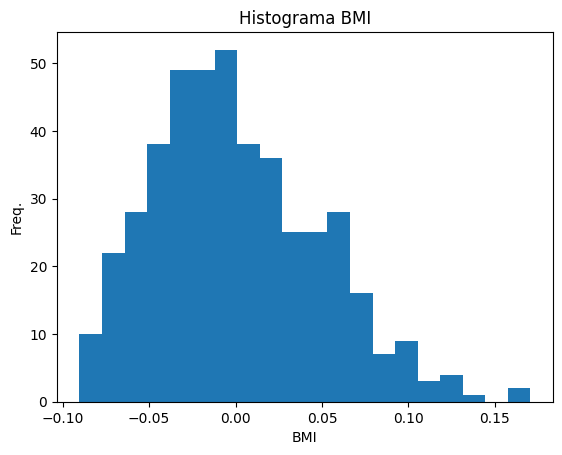

In [11]:
plt.figure()
plt.hist(data["bmi"], bins=20)
plt.title("Histograma BMI")
plt.xlabel("BMI")
plt.ylabel("Freq.")
plt.show()

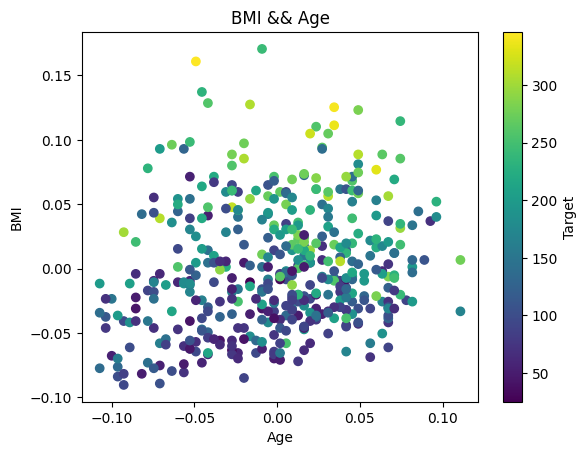

In [20]:
data["target"] = diabetes_dataset.target

plt.figure()
plt.scatter(data["age"], data["bmi"], c=data["target"])
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("BMI && Age")
plt.colorbar(label="Target")
plt.show()

In [26]:
X = data[["bmi"]]
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coef.:", model.coef_)
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)

Coef.: [998.57768914]
Intercept: 152.00335421448167


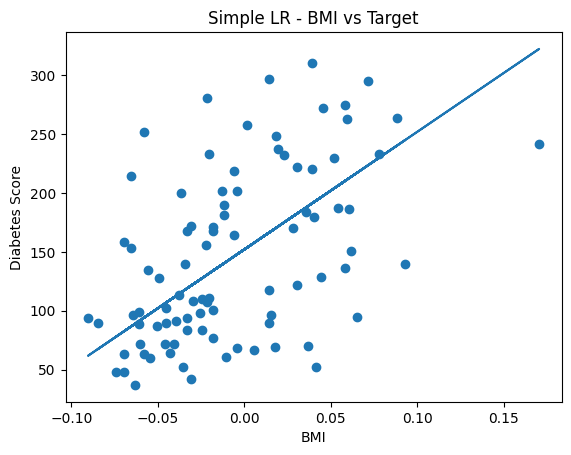

In [28]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)

plt.xlabel("BMI")
plt.ylabel("Diabetes Score")
plt.title("Simple LR - BMI vs Target")
plt.show()

In [32]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 4061.8259284949268


In [34]:
X_2 = data[["bmi", "bp"]]
y = data["target"]

X_2_train, X_2_test, y_train, y_test = train_test_split(X_2, y, test_size=0.2, random_state=42)

modelV2 = LinearRegression()
modelV2.fit(X_2_train, y_train)

print("BMI coef.:", modelV2.coef_[0])
print("BP coef.:", modelV2.coef_[1])
print("Intercept:", modelV2.intercept_)

y_pred2 = modelV2.predict(X_2_test)

r2 = r2_score(y_test, y_pred2)
print("r2:", r2)

BMI coef.: 839.5198533413899
BP coef.: 393.4512031152832
Intercept: 151.8153925749251
r2: 0.2939977566766083
